In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer.library import SaveDensityMatrix
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, CXGate, RYGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter, NullFormatter

# Defining Global Variable and Custom Gates

In [3]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))

H_matrix = HGate().to_matrix()
hadamard_custom = UnitaryGate(H_matrix, label='hadamard_custom')

# Circuit

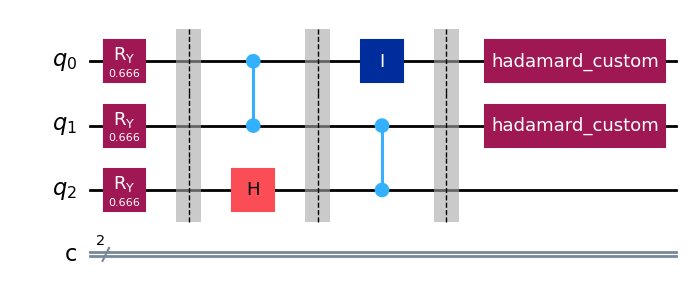

In [4]:
circuit = QuantumCircuit(3, 2)

for i in range(3):
    circuit.ry(theta, i)
circuit.barrier()

circuit.cz(0,1)
circuit.h(2)
circuit.barrier()

circuit.id(0)
circuit.cz(1,2)
circuit.barrier()

circuit.append(hadamard_custom, [0])
circuit.append(hadamard_custom, [1])

display(circuit.draw(output='mpl'))

# Infidelity to Error Rates

In [5]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [6]:
def error_to_inf(error_list, num_qubits):
    inf_list = []
    dim = 2**num_qubits
    for error in error_list:
        inf_list.append(error * (dim - 1)/dim)
        
    return inf_list

In [7]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [8]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

In [9]:
print(one_qubit_gate_error_prob)
print(two_qubit_gate_error_prob)
print(idle_gate_error_prob)

[5.6e-05, 0.000112, 0.000168, 0.000224, 0.00028]
[0.0011066666666666666, 0.002213333333333333, 0.00332, 0.004426666666666666, 0.005533333333333333]
[0.00024, 0.00048, 0.00072, 0.00096, 0.0012000000000000001]


# Ideal Density Matrices

In [10]:
identity = [[1,0], [0,1]]
ry_theta = [[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]]

one_q_zero_dm = np.matmul([[1], [0]], [[1,0]])
ideal = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))

ry_i_i = np.kron(ry_theta, np.kron(identity, identity))
ideal = ry_i_i @ ideal @ ry_i_i.conj().T 

ideal /= np.trace(ideal)
ideal = DensityMatrix(ideal)

# 1 Round

In [11]:
# Store output fidelities for each error-rate setting.
all_fidelity = []

shots = 30

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    # Add depolarizing noise to each operation type.
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['ry']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['h']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(idle_gate_error_prob[i], 1),
        ['id']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(two_qubit_gate_error_prob[i], 2),
        ['cz']
    )
    
    # Add readout errors on the measured qubits.
    readout_err = ReadoutError([
        [1 - spam0[i], spam0[i]],
        [spam1[i], 1 - spam1[i]]
    ])
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    # Measure for post-selection and save the conditional density matrix.
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1])
    meas_circuit_noise.append(
        SaveDensityMatrix(
            num_qubits=3,
            label="dm_post",
            conditional=True,
            pershot=True
        ),
        meas_circuit_noise.qubits
    )

    # Run the noisy density-matrix simulation.
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    # Compute fidelity of the accepted 00 outcome with the ideal output.
    res_dm = result.data()['dm_post']
    all_fidelity.append(
        state_fidelity(res_dm['0x0'][0], ideal, validate=True)
    )

# Convert fidelities to infidelities.
all_infidelity = [1 - f for f in all_fidelity]

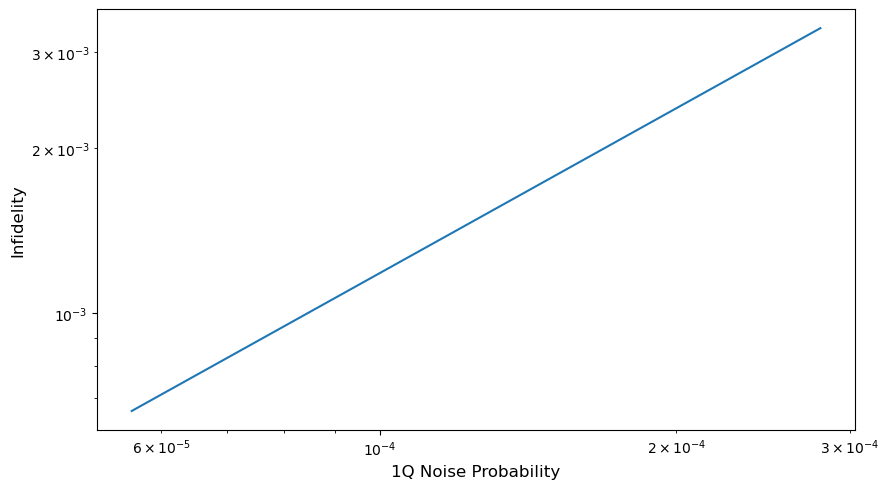

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(one_qubit_gate_error_prob, all_infidelity)
plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()

# Multiple Rounds

Assume the distillation circuit is perfect:

In [20]:
# Number of distillation rounds and simulation shots per round.
rounds = 50
shots = 50

# Initialize the first-round input error rate.
input_error_rate = [one_qubit_gate_error_prob[0]]

# Store the output infidelity after each round.
infidelity_list = []

for r in range(rounds):
    noise_model = NoiseModel()
    
    # Apply depolarizing noise only to the input R_y preparation gates.
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(input_error_rate[r], 1),
        ["ry"]
    )

    # Measure for post-selection and save the conditional density matrix.
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1])
    meas_circuit_noise.append(
        SaveDensityMatrix(
            num_qubits=3,
            label="dm_post",
            conditional=True,
            pershot=True
        ),
        meas_circuit_noise.qubits
    )

    # Run the noisy density-matrix simulation.
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    # Compute the accepted output infidelity.
    res_dm = result.data()['dm_post']
    fidelity = state_fidelity(res_dm['0x0'][0], ideal, validate=True)
    infidelity_list.append(1 - fidelity)

    # Convert the output infidelity into the next round's input error rate.
    new_error_rate_list = inf_to_error([1 - fidelity], 1)
    input_error_rate.append(new_error_rate_list[-1])

output_error_rate = inf_to_error(infidelity_list, 1)

In [21]:
def exp_decay(r, A, lam, C):
    return A * np.exp(-lam * r) + C

rounds_arr = np.array([r+1 for r in range(rounds)])
output_error_rate_arr = np.array(output_error_rate)

popt, pcov = curve_fit(
    exp_decay, 
    rounds_arr, 
    output_error_rate_arr, 
    p0=[output_error_rate_arr[0], 0.1, 0.0],
    maxfev=10000
)

A_fit, lam_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

In [15]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

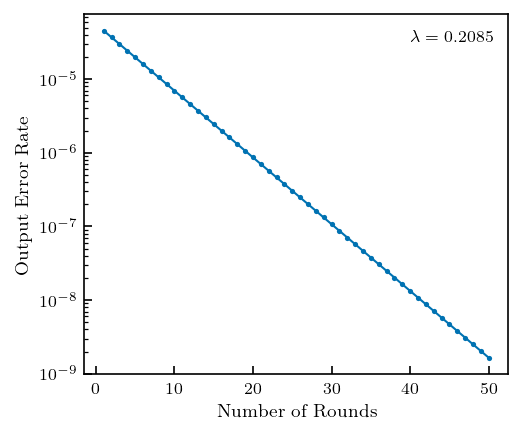

In [26]:
fig, ax = plt.subplots(figsize=(3.375, 2.8))

# Data curve, but excluded from legend
ax.plot(
    rounds_arr,
    output_error_rate_arr,
    'o-',
    color='#0072B2',
    markersize=2.5,
    linewidth=1.0,
    markeredgewidth=0.0,
    zorder=3,
    label='_nolegend_'
)

ax.set_xlabel("Number of Rounds")
ax.set_ylabel("Output Error Rate")

ax.set_yscale('log')

ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

# Legend with text only
dummy = plt.Line2D([], [], linestyle='none', label=rf'$\lambda={lam_fit:.4f}$')
ax.legend(
    handles=[dummy],
    frameon=False,
    loc='upper right',
    handlelength=0,
    handletextpad=0
)

# Remove ticks on the top and right
ax.tick_params(which='both', direction='in', top=False, right=False)

fig.tight_layout(pad=0.4)

Assume the distillation circuit is noisy:

In [ ]:
rounds = 125
shots = 50
input_error_rate = [one_qubit_gate_error_prob[0]]
infidelity_list = []
for r in range(rounds):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(input_error_rate[r], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[0], 1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[0], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[0], 2), ['cz'])
    
    readout_err = ReadoutError([[1-spam0[0], spam0[0]],  # P(0|0), P(1|0)
                            [spam1[0], 1-spam1[0]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1])
    meas_circuit_noise.append(
        SaveDensityMatrix(num_qubits=3, label="dm_post", conditional=True, pershot=True),
        meas_circuit_noise.qubits
    )

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    fidelity = state_fidelity(res_dm['0x0'][0], ideal, validate=True)
    infidelity_list.append(1-fidelity)
    new_error_rate_list = inf_to_error([1-fidelity], 1)
    input_error_rate.append(new_error_rate_list[-1])

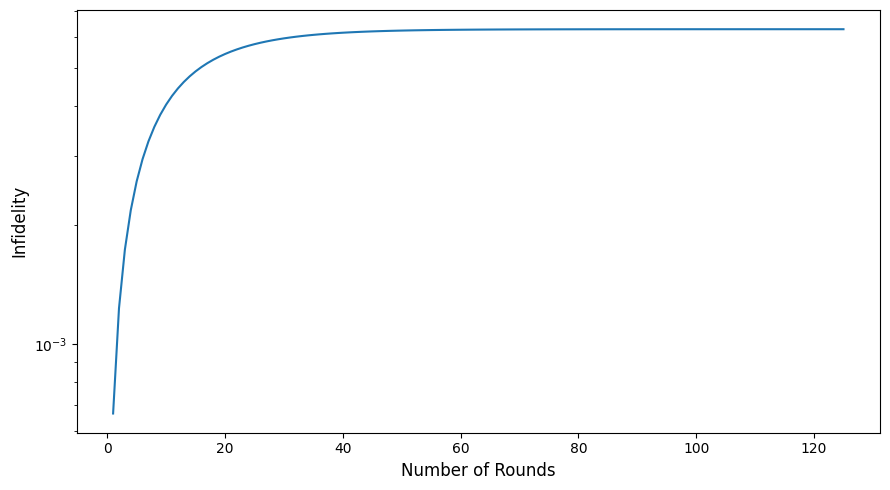

In [13]:
plt.figure(figsize=(9, 5))
plt.plot([r+1 for r in range(rounds)], infidelity_list)
plt.xlabel("Number of Rounds", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
#plt.xscale('log')
plt.tight_layout()
plt.show()

# Saving Data

In [25]:
np.savez(
    "scaling.npz",
    rounds_arr=rounds_arr,
    output_error_rate_arr=output_error_rate_arr,
    lambda_=lam_fit
)